<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/alex/RA1_LAB1/Experiencia_4_Laboratorio_N%C2%B01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio N°1

In [136]:
# @title Importación, visualización, manipulación de datos
import pandas as pd
import sys
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import pickle
import time
import warnings
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, GridSearchCV, KFold)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree,DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC, SVR
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score, balanced_accuracy_score,
                              ConfusionMatrixDisplay, make_scorer, recall_score, mean_absolute_error, mean_squared_error, r2_score)
from sklearn.feature_selection import mutual_info_classif, RFECV, mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
import time
from itertools import combinations
import matplotlib.patches as mpatches


---

## Experiencia 4: Sistema de control de acceso autónomo en espacios comerciales

**Dataset:** `datos_adl.csv`  

**Grupo 8:** — Alex Nahuel Acosta, Santiago Daniel Bareiro, Agustín Marcelo Borges

**Fecha:** — dd/mm/aaaa

---

> Sistema de seguridad basado en visión por computadora para instalaciones comerciales

---

### 0. Carga y exploración de datos

In [105]:
# Archivos pueden arrastrarse al área de trabajo o procesarse en local

# Version Online
!wget https://raw.githubusercontent.com/Santibareiro27/Inteligencia-Computacional/main/RA1_LAB1/datos_bmd.csv

--2026-04-18 19:16:45--  https://raw.githubusercontent.com/Santibareiro27/Inteligencia-Computacional/main/RA1_LAB1/datos_bmd.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50422 (49K) [text/plain]
Saving to: ‘datos_bmd.csv.1’

datos_bmd.csv.1     100%[===================>]  49.24K  --.-KB/s    in 0.004s  

2026-04-18 19:16:45 (11.0 MB/s) - ‘datos_bmd.csv.1’ saved [50422/50422]



In [126]:
# Lectura del dataset
dataset_bmd = pd.read_csv("datos_bmd.csv")
dataset_bmd

,Genero,Edad,CircunferenciaCabeza,AnchoHombro,AnchoPecho,Abdomen,Cintura,Cadera,LongitudBrazo,LongitudHombroCintura,LongitudCinturaRodilla,LongitudPierna,AlturaTotal
0,1.0,30,55.88,45.72,50.80,45.72,35.56,55.88,55.88,63.50,63.50,55.88,132.08
1,1.0,28,48.26,55.88,43.18,45.72,53.34,63.50,71.12,58.42,63.50,50.80,142.24
2,1.0,29,50.80,50.80,45.72,27.94,48.26,35.56,60.96,53.34,50.80,53.34,114.30
3,1.0,23,40.64,40.64,50.80,45.72,55.88,45.72,38.10,66.04,50.80,48.26,101.60
4,1.0,31,38.10,50.80,71.12,45.72,231.14,43.18,40.64,53.34,53.34,48.26,139.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
711,2.0,2,45.72,38.10,20.32,50.80,48.26,50.80,35.56,33.02,27.94,45.72,81.28
712,2.0,10,53.34,30.48,30.48,55.88,60.96,66.04,53.34,38.10,35.56,63.50,114.30
713,2.0,13,55.88,15.24,35.56,63.50,45.72,76.20,53.34,50.80,40.64,83.82,149.86
714,2.0,4,50.80,38.10,25.40,50.80,50.80,53.34,45.72,25.40,30.48,48.26,93.98


In [107]:
# 1. Información general y búsqueda de nulos
print("--- INFORMACIÓN GENERAL ---")
print(dataset_bmd.info())
print("\nValores nulos por columna:")
print(dataset_bmd.isnull().sum())

# 2. Estadísticas descriptivas
print("\n--- ESTADÍSTICAS DESCRIPTIVAS ---")
display(dataset_bmd.describe())

--- INFORMACIÓN GENERAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 716 entries, 0 to 715
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Genero                  715 non-null    float64
 1   Edad                    716 non-null    int64  
 2   CircunferenciaCabeza    716 non-null    float64
 3   AnchoHombro             716 non-null    float64
 4   AnchoPecho              716 non-null    float64
 5   Abdomen                 716 non-null    float64
 6   Cintura                 716 non-null    float64
 7   Cadera                  716 non-null    float64
 8   LongitudBrazo           716 non-null    float64
 9   LongitudHombroCintura   716 non-null    float64
 10  LongitudCinturaRodilla  716 non-null    float64
 11  LongitudPierna          716 non-null    float64
 12  AlturaTotal             716 non-null    float64
dtypes: float64(12), int64(1)
memory usage: 72.8 KB
None

Valores nulos 

,Genero,Edad,CircunferenciaCabeza,AnchoHombro,AnchoPecho,Abdomen,Cintura,Cadera,LongitudBrazo,LongitudHombroCintura,LongitudCinturaRodilla,LongitudPierna,AlturaTotal
count,715.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000,716.000000
mean,1.453147,15.340782,52.258017,36.365279,37.007374,51.307291,48.934022,49.221369,47.795279,45.468128,42.062542,68.157849,122.221536
std,0.498148,11.831501,9.508118,12.095939,13.499202,25.737801,22.277594,22.212866,13.656543,13.663455,13.219205,20.132010,30.878074
min,1.000000,1.000000,12.700000,10.160000,15.240000,12.700000,5.080000,17.780000,15.240000,2.540000,10.160000,22.860000,48.260000
25%,1.000000,7.000000,48.260000,27.940000,27.940000,38.100000,30.480000,30.480000,40.640000,33.020000,33.020000,53.340000,101.600000
50%,1.000000,11.000000,50.800000,35.560000,33.020000,50.800000,50.800000,45.720000,48.260000,44.450000,40.640000,66.040000,121.920000
75%,2.000000,21.000000,55.880000,45.720000,43.180000,58.420000,58.420000,60.960000,55.880000,55.880000,50.800000,81.280000,139.700000
max,2.000000,68.000000,203.200000,220.980000,96.520000,541.020000,231.140000,160.020000,167.640000,99.060000,114.300000,127.000000,226.060000


Se decide eliminar la fila con el valor de genero nulo, porque es 1 fila respecto a 716.


In [108]:
dataset_bmd.dropna(subset=['Genero'], inplace=True)
print("Fila con valor nulo en 'Genero' eliminada.")
print("Valores nulos después de la eliminación:")
print(dataset_bmd.isnull().sum())

Fila con valor nulo en 'Genero' eliminada.
Valores nulos después de la eliminación:
Genero                    0
Edad                      0
CircunferenciaCabeza      0
AnchoHombro               0
AnchoPecho                0
Abdomen                   0
Cintura                   0
Cadera                    0
LongitudBrazo             0
LongitudHombroCintura     0
LongitudCinturaRodilla    0
LongitudPierna            0
AlturaTotal               0
dtype: int64


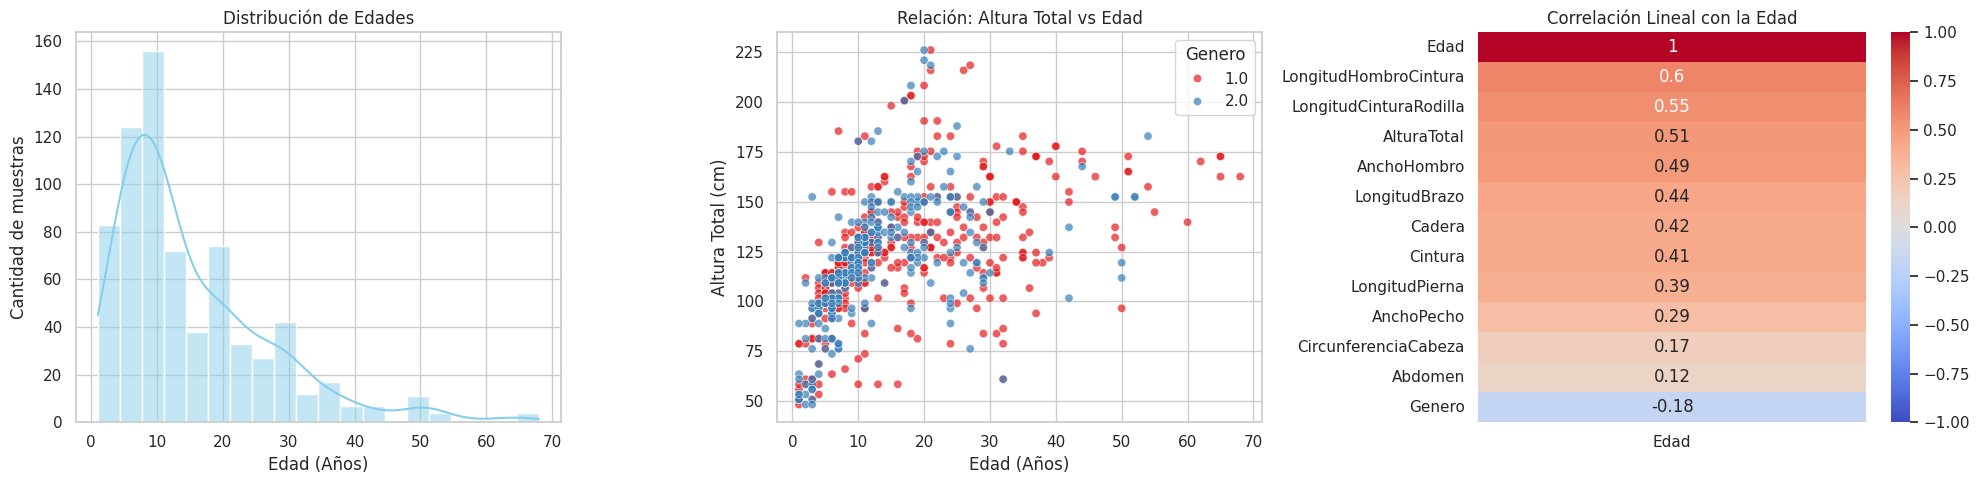

In [109]:
# Análisis visual de las distribuciones y relaciones
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Gráfico A: Distribución de las edades en el dataset
sns.histplot(data=dataset_bmd, x='Edad', bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Edades')
axes[0].set_xlabel('Edad (Años)')
axes[0].set_ylabel('Cantidad de muestras')

# Gráfico B: Altura vs Edad (La relación más intuitiva)
sns.scatterplot(data=dataset_bmd, x='Edad', y='AlturaTotal', hue='Genero', palette='Set1', alpha=0.7, ax=axes[1])
axes[1].set_title('Relación: Altura Total vs Edad')
axes[1].set_xlabel('Edad (Años)')
axes[1].set_ylabel('Altura Total (cm)')

# Gráfico C: Correlación de todas las variables con la Edad
correlaciones = dataset_bmd.corr()[['Edad']].sort_values(by='Edad', ascending=False)
sns.heatmap(correlaciones, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[2])
axes[2].set_title('Correlación Lineal con la Edad')

plt.tight_layout()
plt.show()

Se observa un crecimiento logarítmico en la gráfica de la relación altura vs edad, con una asintota horizontal apartir de los 20 años, lo cual es lógico.
La correlación lineal nos indica que la `AlturaTotal` es el predictor mas fuerte de edad, `LongitudPierna`, `HombroCintura`, `LongitudBrazo`.


In [130]:
#limpieza por lógica de dominio
filtro_logico = (dataset_bmd['AlturaTotal'] > dataset_bmd['LongitudPierna']) & \
                (dataset_bmd['AlturaTotal'] > 40) # Un bebé recién nacido mide ~45cm
dataset_bmd = dataset_bmd[filtro_logico].copy()

Filas antes: 716, después: 706


Text(0.5, 1.0, 'Distribución por variable (tras limpieza)')

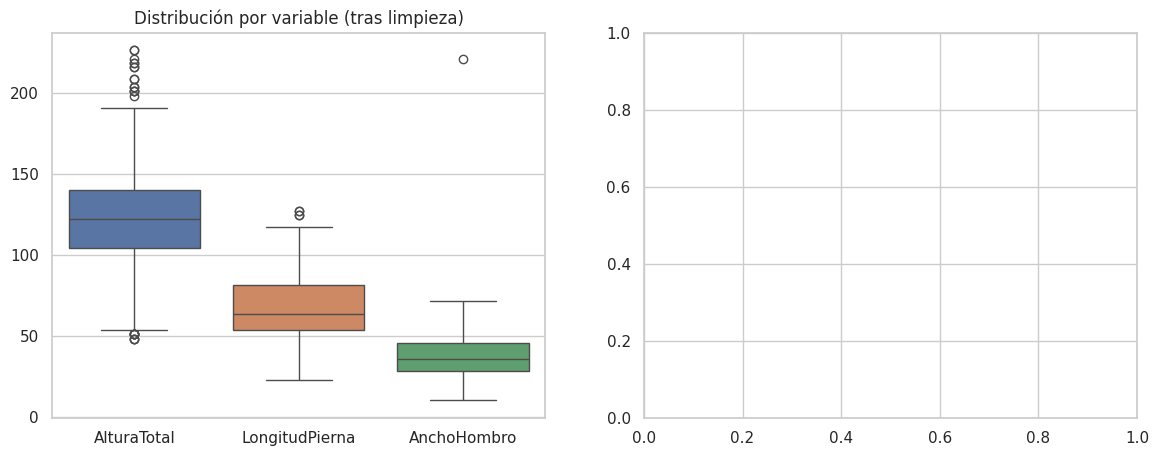

In [131]:
# Antes y después del filtro
print(f"Filas antes: 716, después: {len(dataset_bmd)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=dataset_bmd[['AlturaTotal', 'LongitudPierna', 'AnchoHombro']], ax=axes[0])
axes[0].set_title('Distribución por variable (tras limpieza)')

Se limpiaron datos absurdos.

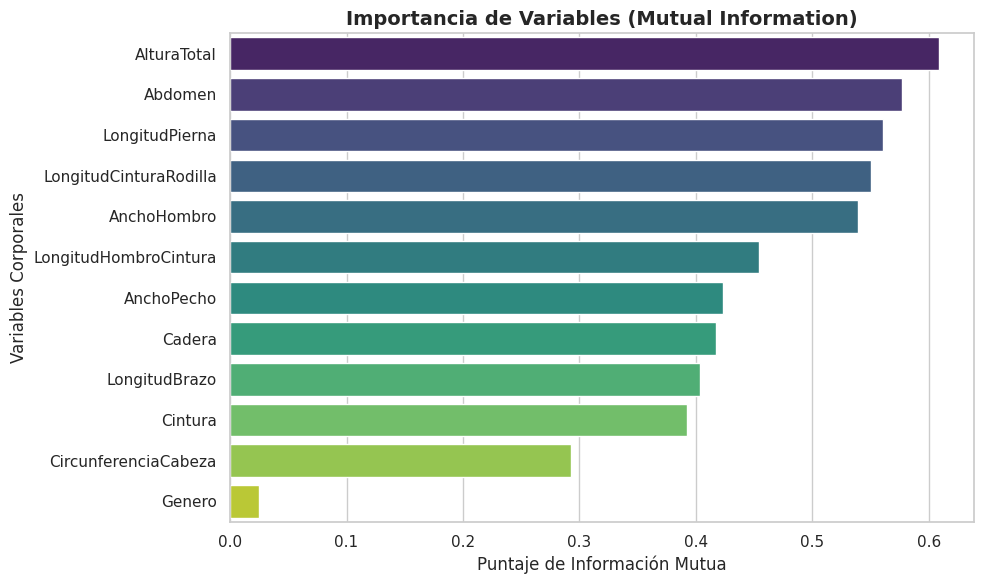

In [112]:
# Calcular Mutual Information
X = dataset_bmd.drop('Edad', axis=1)
y = dataset_bmd['Edad']

mi_scores = mutual_info_regression(X, y, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Gráfico de Información Mutua
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_scores_series.values, y=mi_scores_series.index, palette='viridis', hue=mi_scores_series.index, legend=False)
plt.title('Importancia de Variables (Mutual Information)', fontsize=14, fontweight='bold')
plt.xlabel('Puntaje de Información Mutua', fontsize=12)
plt.ylabel('Variables Corporales', fontsize=12)
plt.tight_layout()
plt.show()

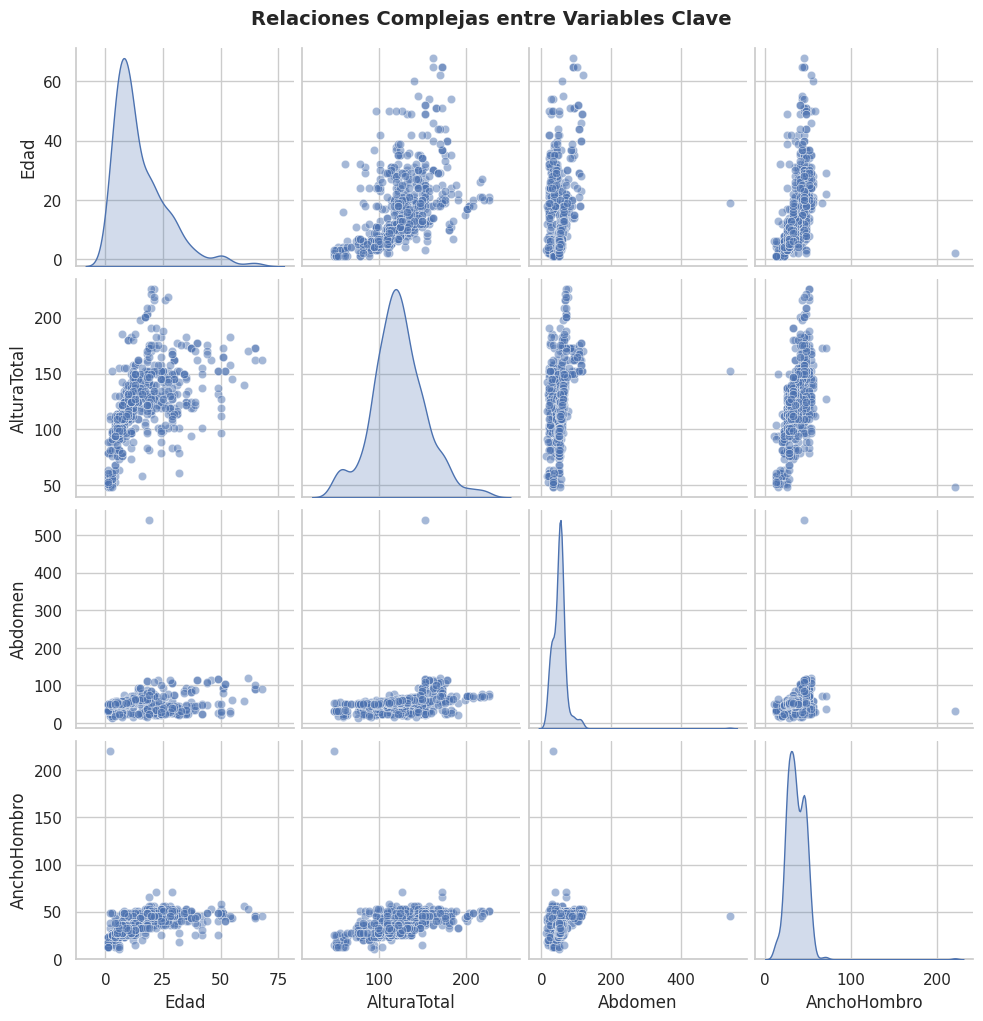

In [113]:
# Pairplot de relaciones no lineales (Mostramos solo las 3 mejores + Edad para no saturar la RAM)
variables_clave = ['Edad', 'AlturaTotal', 'Abdomen', 'AnchoHombro']
sns.pairplot(dataset_bmd[variables_clave], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle('Relaciones Complejas entre Variables Clave', y=1.02, fontsize=14, fontweight='bold')
plt.show()

La `AlturaTotal` demuestra ser la variable con mas información, `Abdomen` y `AnchoHombro` son predictores muy fuertes de edad. ¿El `Genero` no aporta valor predictivo para determinar la edad?

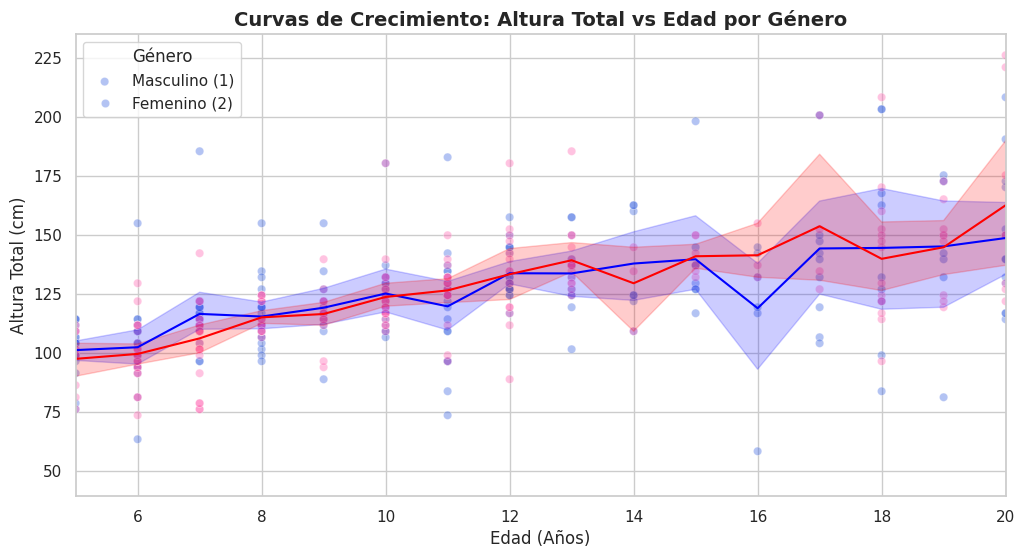

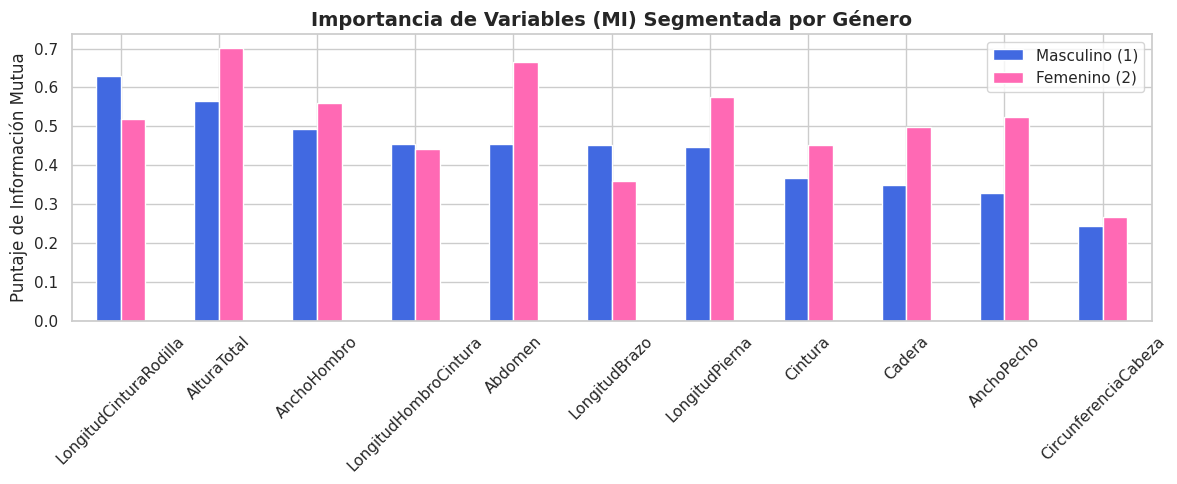

In [133]:
# GRÁFICO: Altura vs Edad coloreado por Género (Visualización de la Pubertad)
plt.figure(figsize=(12, 6))
# Usamos un scatter con baja opacidad y una línea de tendencia (regresión no lineal)
sns.scatterplot(data=dataset_bmd, x='Edad', y='AlturaTotal', hue='Genero',
                palette={1: 'royalblue', 2: 'hotpink'}, alpha=0.4)
sns.lineplot(data=dataset_bmd, x='Edad', y='AlturaTotal', hue='Genero',
             palette={1: 'blue', 2: 'red'}, legend=False)

plt.title('Curvas de Crecimiento: Altura Total vs Edad por Género', fontsize=14, fontweight='bold')
plt.xlabel('Edad (Años)')
plt.ylabel('Altura Total (cm)')
plt.xlim(5, 20) # Hacemos foco en el rango de crecimiento crítico
plt.legend(title='Género', labels=['Masculino (1)', 'Femenino (2)'])
plt.show()

# CÁLCULO DE MI POR GÉNERO SEPARADO
def calcular_mi_por_genero(df, genero_id):
    sub_df = df[df['Genero'] == genero_id]
    X_sub = sub_df.drop(['Edad', 'Genero'], axis=1)
    y_sub = sub_df['Edad']
    scores = mutual_info_regression(X_sub, y_sub, random_state=42)
    return pd.Series(scores, index=X_sub.columns)

mi_masculino = calcular_mi_por_genero(dataset_bmd, 1)
mi_femenino = calcular_mi_por_genero(dataset_bmd, 2)

# Crear DataFrame comparativo
df_mi_comp = pd.DataFrame({
    'Masculino (1)': mi_masculino,
    'Femenino (2)': mi_femenino
}).sort_values(by='Masculino (1)', ascending=False)

# GRÁFICO: Comparativa de Importancia de Variables por Género
df_mi_comp.plot(kind='bar', figsize=(12, 5), color=['royalblue', 'hotpink'])
plt.title('Importancia de Variables (MI) Segmentada por Género', fontsize=14, fontweight='bold')
plt.ylabel('Puntaje de Información Mutua')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

El análisis de MI por separado revela que la jerarquía de importancia de las variables cambia según el sexo:

*   En el Género Femenino, variables como la Cadera y el Abdomen adquieren un peso predictivo ligeramente superior durante la adolescencia temprana.

*   En el Género Masculino, el Ancho de Hombro y la Longitud del Brazo muestran una correlación más fuerte con el avance de la edad hacia la adultez joven.



Text(0.5, 1.0, 'Distribución de muestras por rango etario')

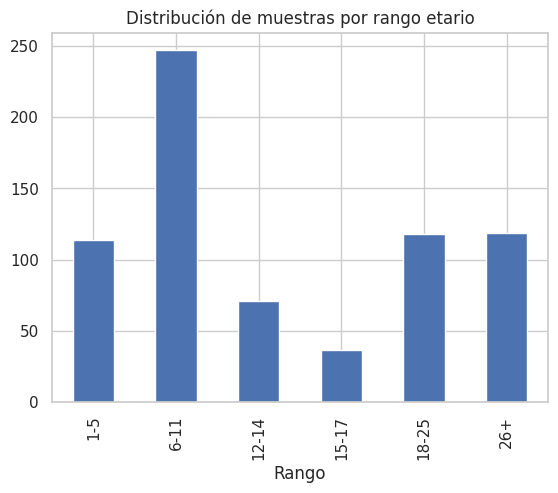

In [135]:
# Distribución de muestras por rango etario
bins = [0, 5, 11, 14, 17, 25, 100]
labels = ['1-5', '6-11', '12-14', '15-17', '18-25', '26+']
dataset_bmd['Rango'] = pd.cut(dataset_bmd['Edad'], bins=bins, labels=labels)
dataset_bmd['Rango'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribución de muestras por rango etario')

Se puede observar que hay mas muestras de 6-11 años.

## 1. Busqueda y determinación del mejor modelo de predicción

Sabemos que los mejores modelos de predicción serán los no lineales debido al comportamiento de los datos.


--- EVALUACIÓN DE MODELOS DE REGRESIÓN ---
Evaluando: Linear Regression...
  MAE Promedio: 5.99 años (+/- 0.38 años)
  RMSE Promedio: 9.19 años (+/- 3.67 años)
  R2 Promedio: 0.34 (+/- 0.26)
Evaluando: Decision Tree Regressor...
  MAE Promedio: 4.98 años (+/- 0.34 años)
  RMSE Promedio: 9.63 años (+/- 3.54 años)
  R2 Promedio: 0.31 (+/- 0.10)
Evaluando: K-Neighbors Regressor...
  MAE Promedio: 4.04 años (+/- 0.40 años)
  RMSE Promedio: 7.08 años (+/- 3.68 años)
  R2 Promedio: 0.63 (+/- 0.06)
Evaluando: Support Vector Regressor...
  MAE Promedio: 4.69 años (+/- 0.68 años)
  RMSE Promedio: 8.36 años (+/- 4.90 años)
  R2 Promedio: 0.51 (+/- 0.08)
Evaluando: Random Forest Regressor...
  MAE Promedio: 3.84 años (+/- 0.60 años)
  RMSE Promedio: 7.01 años (+/- 4.14 años)
  R2 Promedio: 0.65 (+/- 0.06)
Evaluando: Gradient Boosting Regressor...
  MAE Promedio: 4.22 años (+/- 0.56 años)
  RMSE Promedio: 7.28 años (+/- 4.41 años)
  R2 Promedio: 0.62 (+/- 0.07)

--- RESUMEN DE RENDIMIENTO DE MODE

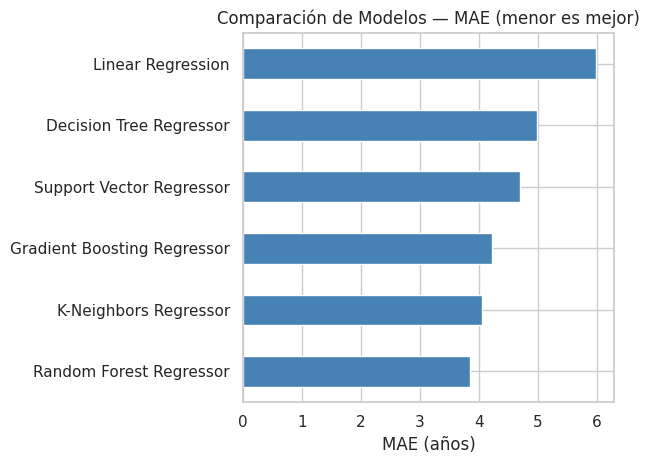

In [139]:
# Re-using X and y defined previously
X = dataset_bmd.drop(['Edad', 'Genero', 'Rango'], axis=1)
y = dataset_bmd['Edad']

# Definir los modelos a comparar
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'K-Neighbors Regressor': KNeighborsRegressor(),
    'Support Vector Regressor': SVR(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}

# Crear scorers para MAE, MSE y R-squared
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
r2_scorer = make_scorer(r2_score, greater_is_better=True)

results = {}

print("\n--- EVALUACIÓN DE MODELOS DE REGRESIÓN ---")
for name, model in models.items():
    print(f"Evaluando: {name}...")

    # Crear un pipeline con StandardScaler y el modelo
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('regressor', model)
    ])

    # Usar K-Fold Cross-Validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # Calcular cross_val_score para MAE, MSE y R2
    mae_scores = -cross_val_score(pipeline, X, y, cv=kf, scoring=mae_scorer)
    mse_scores = -cross_val_score(pipeline, X, y, cv=kf, scoring=mse_scorer)
    r2_scores = cross_val_score(pipeline, X, y, cv=kf, scoring=r2_scorer)

    results[name] = {
        'MAE Mean [AÑOS]': mae_scores.mean(),
        'MAE Std [AÑOS]': mae_scores.std(),
        'RMSE Mean [AÑOS]': np.sqrt(mse_scores.mean()),
        'RMSE Std [AÑOS]': np.sqrt(mse_scores.std()),
        'R2 Mean': r2_scores.mean(),
        'R2 Std': r2_scores.std()
    }

    print(f"  MAE Promedio: {results[name]['MAE Mean [AÑOS]']:.2f} años (+/- {results[name]['MAE Std [AÑOS]']:.2f} años)")
    print(f"  RMSE Promedio: {results[name]['RMSE Mean [AÑOS]']:.2f} años (+/- {results[name]['RMSE Std [AÑOS]']:.2f} años)")
    print(f"  R2 Promedio: {results[name]['R2 Mean']:.2f} (+/- {results[name]['R2 Std']:.2f})")

# Mostrar resultados en un DataFrame para mejor comparación
results_df = pd.DataFrame(results).T.sort_values(by='MAE Mean [AÑOS]')
print("\n--- RESUMEN DE RENDIMIENTO DE MODELOS ---")
results_df['MAE Mean [AÑOS]'].sort_values().plot(kind='barh', color='steelblue')
plt.title('Comparación de Modelos — MAE (menor es mejor)')
plt.xlabel('MAE (años)')
plt.tight_layout()

Podemos observar que el mejor modelo es el Random Forest según la MAE.

In [143]:
# 1. FEATURE ENGINEERING (Ingeniería de Características: Creando Ratios)
# Creamos proporciones dividiendo las medidas clave por la Altura Total
dataset_bmd['Ratio_Cabeza_Altura'] = dataset_bmd['CircunferenciaCabeza'] / dataset_bmd['AlturaTotal']
dataset_bmd['Ratio_Pierna_Altura'] = dataset_bmd['LongitudPierna'] / dataset_bmd['AlturaTotal']
dataset_bmd['Ratio_Hombro_Altura'] = dataset_bmd['AnchoHombro'] / dataset_bmd['AlturaTotal']
dataset_bmd['Ratio_Cintura_Altura'] = dataset_bmd['Cintura'] / dataset_bmd['AlturaTotal']

# 2. Comprobación empírica: ¿Son mejores los Ratios?
X_todas = dataset_bmd.drop(['Edad', 'Genero', 'Rango'], axis=1)
y = dataset_bmd['Edad']

mi_scores_ratios = mutual_info_regression(X_todas, y, random_state=42)
mi_series = pd.Series(mi_scores_ratios, index=X_todas.columns).sort_values(ascending=False)

print("--- IMPORTANCIA DE VARIABLES (MEDIDAS CRUDAS VS RATIOS) ---")
print(mi_series.head(8)) # Mostramos las 8 mejores

# 3. PRUEBA DE CONCEPTO: EL MODELO ADAPTABLE (Regresión)
# Usaremos las medidas originales + Ratios
X_train, X_test, y_train, y_test = train_test_split(X_todas, y, test_size=0.2, random_state=42)

# Entrenamos un Regresor
regresor = RandomForestRegressor(n_estimators=100, random_state=42)
regresor.fit(X_train, y_train)

# Predecimos la EDAD EXACTA en el conjunto de prueba
y_pred_edad = regresor.predict(X_test)
error_promedio = mean_absolute_error(y_test, y_pred_edad)

print(f"\n--- RENDIMIENTO DEL MODELO DE REGRESIÓN ---")
print(f"Error Medio Absoluto (MAE): El modelo le erra por +/- {error_promedio:.2f} años.")

# 4. SIMULACIÓN DEL PANEL DE CONTROL (Umbral Dinámico)
def simular_puerta(edad_real, edad_predicha, umbral_cliente):
    es_nino_real = edad_real < umbral_cliente
    es_nino_predicho = edad_predicha < umbral_cliente

    if es_nino_real and es_nino_predicho: return "Verdadero Positivo (Bloqueo exitoso)"
    if not es_nino_real and not es_nino_predicho: return "Verdadero Negativo (Paso libre)"
    if not es_nino_real and es_nino_predicho: return "Falso Positivo (Adulto bloqueado por error)"
    if es_nino_real and not es_nino_predicho: return "Falso Negativo (NIÑO ESCAPÓ - RIESGO)"

# Probamos con un umbral de 14 años y luego de 12 años sin reentrenar
df_resultados = pd.DataFrame({
    'Edad Real': y_test.values[:5],
    'Edad Predicha': np.round(y_pred_edad[:5], 1),
    'Acción (Umbral 14)': [simular_puerta(r, p, 14) for r, p in zip(y_test.values[:5], y_pred_edad[:5])],
    'Acción (Umbral 12)': [simular_puerta(r, p, 12) for r, p in zip(y_test.values[:5], y_pred_edad[:5])]
})

print("\n--- SIMULACIÓN DE PUERTA (SIN REENTRENAR EL MODELO) ---")
print(df_resultados.to_string(index=False))

--- IMPORTANCIA DE VARIABLES (MEDIDAS CRUDAS VS RATIOS) ---
AlturaTotal               0.604338
Abdomen                   0.577893
AnchoHombro               0.570844
LongitudCinturaRodilla    0.570428
LongitudPierna            0.549264
Ratio_Cabeza_Altura       0.534127
LongitudBrazo             0.441625
LongitudHombroCintura     0.429074
dtype: float64

--- RENDIMIENTO DEL MODELO DE REGRESIÓN ---
Error Medio Absoluto (MAE): El modelo le erra por +/- 4.83 años.

--- SIMULACIÓN DE PUERTA (SIN REENTRENAR EL MODELO) ---
 Edad Real  Edad Predicha                    Acción (Umbral 14)                    Acción (Umbral 12)
         6           18.9 Falso Negativo (NIÑO ESCAPÓ - RIESGO) Falso Negativo (NIÑO ESCAPÓ - RIESGO)
        35           26.2       Verdadero Negativo (Paso libre)       Verdadero Negativo (Paso libre)
        17           15.9       Verdadero Negativo (Paso libre)       Verdadero Negativo (Paso libre)
        22           19.9       Verdadero Negativo (Paso libre)       

In [147]:
# Identify ratio columns
ratio_cols = [col for col in X_train.columns if 'Ratio' in col]

# Modelo SIN ratios
# Create feature sets without ratios from the existing X_train and X_test
X_train_crudo = X_train.drop(columns=ratio_cols)
X_test_crudo = X_test.drop(columns=ratio_cols)

rf_crudo = RandomForestRegressor(n_estimators=100, random_state=42)
rf_crudo.fit(X_train_crudo, y_train)
mae_crudo = mean_absolute_error(y_test, rf_crudo.predict(X_test_crudo))

# Modelo CON ratios
# X_train and X_test already contain ratios from the split in cell _eixhr0x9gFq
X_train_ratio = X_train
X_test_ratio = X_test

rf_ratio = RandomForestRegressor(n_estimators=100, random_state=42)
rf_ratio.fit(X_train_ratio, y_train)
mae_ratio = mean_absolute_error(y_test, rf_ratio.predict(X_test_ratio))

print(f"MAE sin ratios: {mae_crudo:.2f} | MAE con ratios: {mae_ratio:.2f}")

MAE sin ratios: 4.78 | MAE con ratios: 4.83


In [150]:
# 1. Modelado
X = dataset_bmd.drop(['Edad', 'Genero', 'Rango'], axis=1)
y = dataset_bmd['Edad']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regresor = RandomForestRegressor(n_estimators=100, random_state=42)
regresor.fit(X_train, y_train)

y_pred = regresor.predict(X_test)

# 2. Análisis de Errores por Rango Etario
resultados = pd.DataFrame({'Edad_Real': y_test, 'Edad_Predicha': y_pred})
resultados['Error_Absoluto'] = np.abs(resultados['Edad_Real'] - resultados['Edad_Predicha'])

# Definir rangos etarios críticos
bins = [0, 5, 11, 14, 17, 25, 100]
labels = ['Bebés/Infantes (1-5)', 'Niños (6-11)', 'Preadolescentes (12-14)', 'Adolescentes (15-17)', 'Adultos Jóvenes (18-25)', 'Adultos (26+)']
resultados['Rango_Etario'] = pd.cut(resultados['Edad_Real'], bins=bins, labels=labels)

# Agrupar y calcular MAE por rango
analisis_error = resultados.groupby('Rango_Etario', observed=False).agg(
    Muestras=('Edad_Real', 'count'),
    MAE=('Error_Absoluto', 'mean')
).reset_index()

analisis_error['MAE'] = analisis_error['MAE'].round(2)
print("--- ERROR MEDIO ABSOLUTO (MAE) POR RANGO ETARIO ---")
print(analisis_error.to_string(index=False))

--- ERROR MEDIO ABSOLUTO (MAE) POR RANGO ETARIO ---
           Rango_Etario  Muestras   MAE
   Bebés/Infantes (1-5)        23  1.20
           Niños (6-11)        44  2.26
Preadolescentes (12-14)        15  3.98
   Adolescentes (15-17)         8  4.29
Adultos Jóvenes (18-25)        21  3.47
          Adultos (26+)        31 12.65


In [151]:
sns.set_theme(style="whitegrid")

# ==============================================================================
# 1. MEJORA DEL MODELO: Optimización de Hiperparámetros
# ==============================================================================
print("Buscando los mejores hiperparámetros para el Random Forest...")
# Definimos una grilla de parámetros para que pruebe combinaciones
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Usamos GridSearchCV para encontrar el mejor modelo (con validación cruzada)
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           scoring='neg_mean_absolute_error',
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

# El mejor modelo encontrado
mejor_rf = grid_search.best_estimator_
y_pred_mejorado = mejor_rf.predict(X_test)
mae_mejorado = mean_absolute_error(y_test, y_pred_mejorado)

print(f"Mejor MAE Global alcanzado: {mae_mejorado:.2f} años")
print(f"Mejores parámetros: {grid_search.best_params_}\n")

Buscando los mejores hiperparámetros para el Random Forest...
Mejor MAE Global alcanzado: 4.87 años
Mejores parámetros: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}



In [152]:
# ==============================================================================
# 2. Análisis de Errores por Rango Etario (USANDO EL MODELO OPTIMIZADO)
# ==============================================================================

# IMPORTANTE: Ya NO creamos ni entrenamos un "regresor" nuevo.
# Usamos directamente las predicciones (y_pred_mejorado) del mejor modelo (mejor_rf)
# que encontramos en el paso de GridSearchCV.

resultados = pd.DataFrame({'Edad_Real': y_test, 'Edad_Predicha': y_pred_mejorado})
resultados['Error_Absoluto'] = np.abs(resultados['Edad_Real'] - resultados['Edad_Predicha'])

# Definir rangos etarios críticos
bins = [0, 5, 11, 14, 17, 25, 100]
labels = ['Bebés/Infantes (1-5)', 'Niños (6-11)', 'Preadolescentes (12-14)', 'Adolescentes (15-17)', 'Adultos Jóvenes (18-25)', 'Adultos (26+)']
resultados['Rango_Etario'] = pd.cut(resultados['Edad_Real'], bins=bins, labels=labels)

# Agrupar y calcular MAE por rango
analisis_error = resultados.groupby('Rango_Etario', observed=False).agg(
    Muestras=('Edad_Real', 'count'),
    MAE=('Error_Absoluto', 'mean')
).reset_index()

analisis_error['MAE'] = analisis_error['MAE'].round(2)
print("--- ERROR MEDIO ABSOLUTO (MAE) POR RANGO ETARIO (MODELO OPTIMIZADO) ---")
print(analisis_error.to_string(index=False))

--- ERROR MEDIO ABSOLUTO (MAE) POR RANGO ETARIO (MODELO OPTIMIZADO) ---
           Rango_Etario  Muestras   MAE
   Bebés/Infantes (1-5)        23  1.37
           Niños (6-11)        44  2.21
Preadolescentes (12-14)        15  3.97
   Adolescentes (15-17)         8  4.23
Adultos Jóvenes (18-25)        21  3.33
          Adultos (26+)        31 12.89


In [153]:
# 1. Extraer los resultados completos del diccionario cv_results_
resultados_grid = pd.DataFrame(grid_search.cv_results_)

# 2. Convertir el score negativo (neg_mean_absolute_error) a MAE positivo
resultados_grid['MAE_Validacion'] = -resultados_grid['mean_test_score']

# 3. Filtrar las columnas útiles y renombrarlas para que queden presentables
columnas_parametros = ['param_max_depth', 'param_n_estimators', 'param_min_samples_split', 'param_min_samples_leaf', 'MAE_Validacion']
top_5 = resultados_grid.sort_values(by='MAE_Validacion').head(5)[columnas_parametros]

top_5.columns = ['Profundidad Máxima', 'Cant. Árboles', 'Mín. División', 'Mín. Hoja', 'MAE (Años)']

# Rellenar los valores "None" (sin límite) con un texto legible
top_5['Profundidad Máxima'] = top_5['Profundidad Máxima'].fillna('Sin límite')

# 4. Mostrar la tabla de forma profesional
print("--- TOP 5 COMBINACIONES DE HIPERPARÁMETROS ---")
from IPython.display import display, HTML
display(HTML(top_5.to_html(index=False, classes='table table-striped', justify='center')))

--- TOP 5 COMBINACIONES DE HIPERPARÁMETROS ---


Profundidad Máxima,Cant. Árboles,Mín. División,Mín. Hoja,MAE (Años)
15,200,2,2,3.760261
Sin límite,200,2,2,3.761592
Sin límite,200,5,2,3.766111
15,200,5,2,3.767418
10,100,5,2,3.773055


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Bebés/Infantes (1-5)'),
  Text(1, 0, 'Niños (6-11)'),
  Text(2, 0, 'Preadolescentes (12-14)'),
  Text(3, 0, 'Adolescentes (15-17)'),
  Text(4, 0, 'Adultos Jóvenes (18-25)'),
  Text(5, 0, 'Adultos (26+)')])

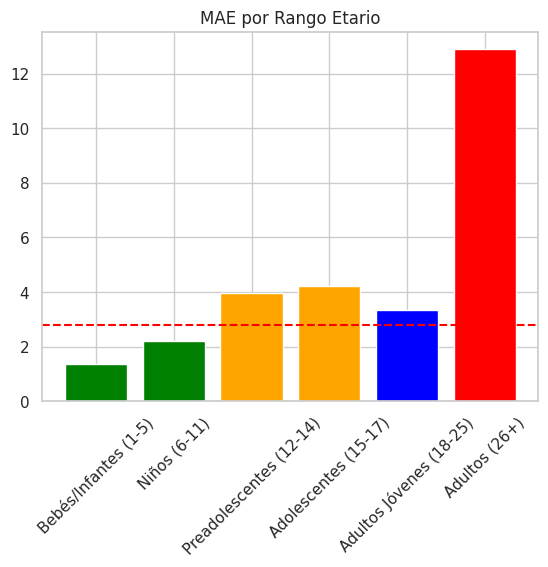

In [154]:
colores = ['green', 'green', 'orange', 'orange', 'blue', 'red']
plt.bar(analisis_error['Rango_Etario'], analisis_error['MAE'], color=colores)
plt.axhline(y=2.8, color='red', linestyle='--', label='MAE crítico')
plt.title('MAE por Rango Etario')
plt.xticks(rotation=45)

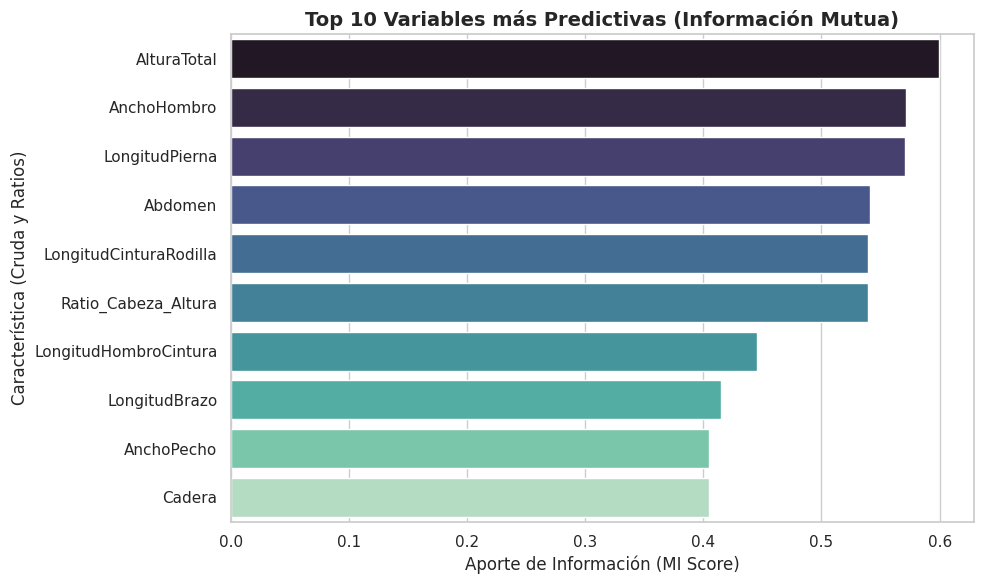

In [118]:
# ==============================================================================
# GRÁFICO 1: Importancia de Variables (Ratios vs Crudas)
# Ideal para insertar después del párrafo de "Información Mutua"
# ==============================================================================
plt.figure(figsize=(10, 6))
# Usamos mi_series que calculaste en el paso anterior
sns.barplot(x=mi_series.head(10).values, y=mi_series.head(10).index, palette='mako', hue=mi_series.head(10).index, legend=False)
plt.title('Top 10 Variables más Predictivas (Información Mutua)', fontsize=14, fontweight='bold')
plt.xlabel('Aporte de Información (MI Score)', fontsize=12)
plt.ylabel('Característica (Cruda y Ratios)', fontsize=12)
plt.tight_layout()
plt.show()

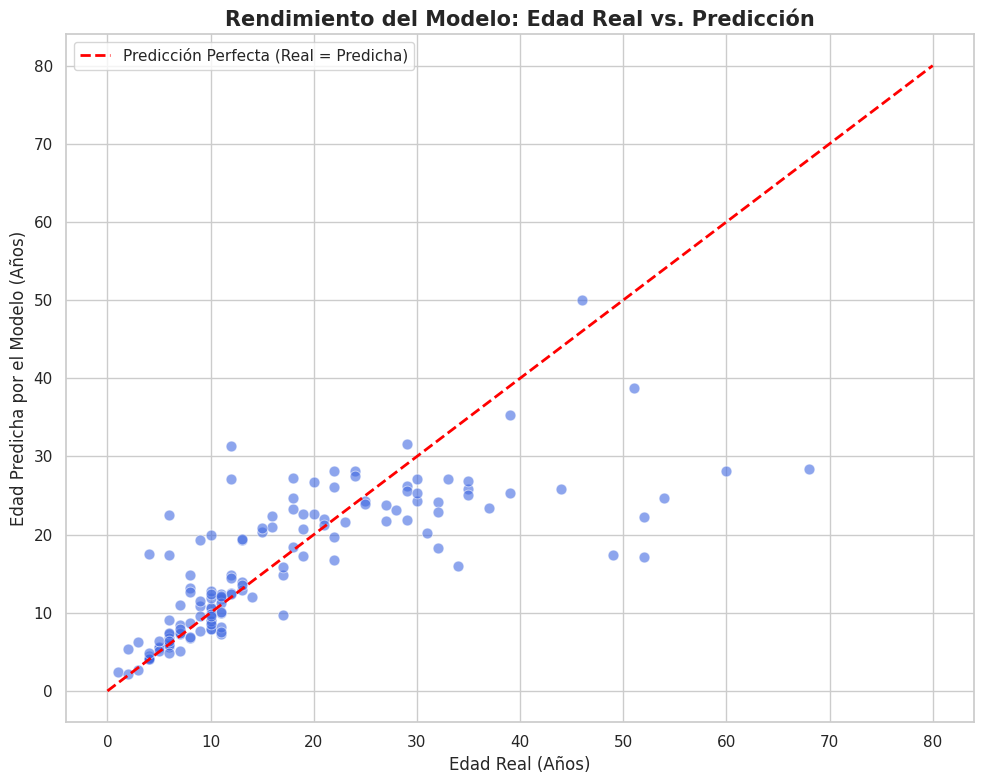

In [119]:
# ==============================================================================
# GRÁFICO 2: Edad Real vs Edad Predicha (Comportamiento Asintótico)
# Ideal para insertar en la sección de "Análisis de Errores por Rango Etario"
# ==============================================================================
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred_mejorado, alpha=0.6, color='royalblue', edgecolor='w', s=60)

# Línea de predicción perfecta
plt.plot([0, 80], [0, 80], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta (Real = Predicha)')

plt.title('Rendimiento del Modelo: Edad Real vs. Predicción', fontsize=15, fontweight='bold')
plt.xlabel('Edad Real (Años)', fontsize=12)
plt.ylabel('Edad Predicha por el Modelo (Años)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


--- CARGA OPERATIVA DEL SISTEMA (TEST SET) ---
  Acción del Sistema  Cantidad de Personas
  VERDE (Paso Libre)                    61
 AMARILLO (Revisión)                    12
ROJO (Bloqueo Total)                    69

⚠️ RIESGO CRÍTICO: Menores de 14 años que pasaron en VERDE: 8


Text(0.5, 1.0, 'Validación Cuantitativa: Lógica de Acceso (Umbral: 14 años)')

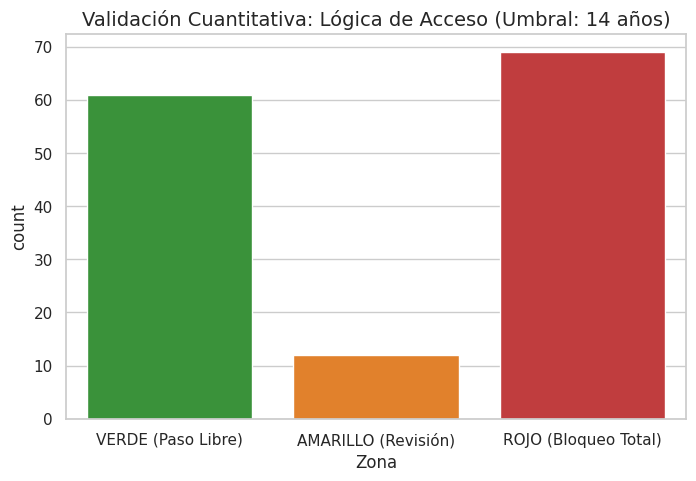

In [159]:
# ==============================================================================
# SIMULACIÓN CUANTITATIVA DEL SEMÁFORO EN EL CONJUNTO DE PRUEBA
# ==============================================================================

def zona_semaforo(edad_predicha, umbral, mae):
    # Condición Verde: La predicción supera el umbral + el margen de error
    if edad_predicha >= umbral + mae:
        return 'VERDE (Paso Libre)'
    # Condición Rojo: La predicción es claramente inferior al umbral (damos 1 año de tolerancia)
    elif edad_predicha < umbral - 1:
        return 'ROJO (Bloqueo Total)'
    # Condición Amarilla: Todo lo que cae en el medio (Margen de duda)
    else:
        return 'AMARILLO (Revisión)'

umbral_cliente = 14
mae_critico = 2.8 # Error en la zona de preadolescentes

# Aplicamos la función a todas las predicciones usando y_pred_mejorado
zonas_asignadas = [zona_semaforo(p, umbral_cliente, mae_critico) for p in y_pred_mejorado]

# Armamos un DataFrame para ver qué pasó
df_semaforo = pd.DataFrame({
    'Edad_Real': y_test,
    'Edad_Predicha': y_pred_mejorado,
    'Zona': zonas_asignadas
})

# Contamos cuántas personas cayeron en cada zona
conteo_zonas = df_semaforo['Zona'].value_counts().reindex(
    ['VERDE (Paso Libre)', 'AMARILLO (Revisión)', 'ROJO (Bloqueo Total)'], fill_value=0
)

# Imprimimos la tabla de resultados
print("\n--- CARGA OPERATIVA DEL SISTEMA (TEST SET) ---")
print(conteo_zonas.reset_index().rename(columns={'Zona': 'Acción del Sistema', 'count': 'Cantidad de Personas'}).to_string(index=False))

# Verificación de Seguridad Crítica: ¿Algún niño real < 14 años pasó en Verde?
falsos_negativos = df_semaforo[(df_semaforo['Edad_Real'] < umbral_cliente) & (df_semaforo['Zona'] == 'VERDE (Paso Libre)')]
print(f"\n⚠️ RIESGO CRÍTICO: Menores de {umbral_cliente} años que pasaron en VERDE: {len(falsos_negativos)}")

# GRÁFICO 4: Distribución de la Carga Operativa
plt.figure(figsize=(8, 5))
colores_semaforo = {'VERDE (Paso Libre)': '#2ca02c', 'AMARILLO (Revisión)': '#ff7f0e', 'ROJO (Bloqueo Total)': '#d62728'}

sns.countplot(data=df_semaforo, x='Zona', hue='Zona', palette=colores_semaforo, order=['VERDE (Paso Libre)', 'AMARILLO (Revisión)', 'ROJO (Bloqueo Total)'], legend=False)

plt.title(f'Validación Cuantitativa: Lógica de Acceso (Umbral: {umbral_cliente} años)', fontsize=14)